# ROC Curve Utilities (Pure NumPy Version)

This version does **not** require scikit-learn and will work on any Python+NumPy setup.
---


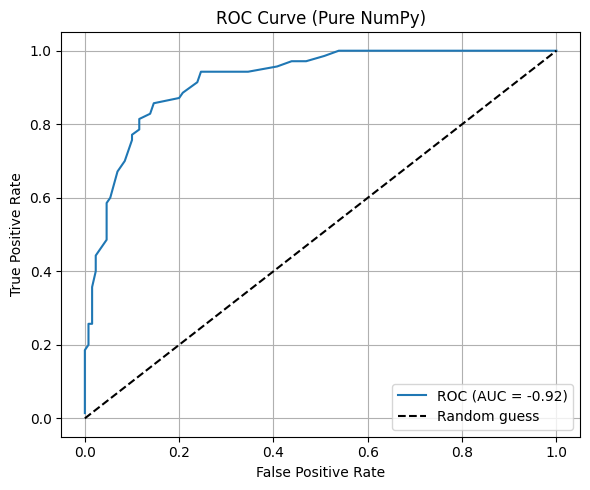

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def roc_curve_np(labels, scores, n_thresholds=100):
    """
    Compute ROC curve using only numpy (no sklearn).
    labels: array of 0 (neg) or 1 (pos)
    scores: continuous detector output (higher=more likely target)
    Returns fpr, tpr arrays.
    """
    thresholds = np.linspace(np.min(scores), np.max(scores), n_thresholds)
    tpr = []
    fpr = []
    for thr in thresholds:
        tp = np.sum((scores >= thr) & (labels == 1))
        fp = np.sum((scores >= thr) & (labels == 0))
        fn = np.sum((scores < thr) & (labels == 1))
        tn = np.sum((scores < thr) & (labels == 0))
        tpr.append(tp / (tp + fn + 1e-10))
        fpr.append(fp / (fp + tn + 1e-10))
    return np.array(fpr), np.array(tpr)

def plot_roc_curve_np(labels, scores, title='ROC Curve'):
    fpr, tpr = roc_curve_np(labels, scores)
    auc_val = np.trapz(tpr, fpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC (AUC = {auc_val:.2f})')
    plt.plot([0,1], [0,1], 'k--', label='Random guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- DEMO: Synthetic detector output ---
np.random.seed(42)
n = 200
labels = np.zeros(n)
labels[:70] = 1
scores = np.random.normal(2, 1, 70).tolist() + np.random.normal(0, 1, 130).tolist()
scores = np.array(scores)

plot_roc_curve_np(labels, scores, title='ROC Curve (Pure NumPy)')


---
- This ROC code does NOT require scikit-learn.
- Use with any detector, classifier, or matched filter output.
- AUC > 0.8 indicates a strong detector; 0.5 is random.

**You can now benchmark detection performance on any system!**
